<a href="https://colab.research.google.com/github/ravindyaparami/multi-agents-on-a-lie-group/blob/main/Mugas_Decentralized_Multi_Agent_Systems_Lie_Groups.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Overview: Geometric Virtual Structure and Tracking Control for Multi Agent Systems on Lie Groups

This repository summarizes the geometric control framework for a network of fullyactuated simple mechanical systems evolving on a Lie group $ G $.  
The framework extends the **AGLES-PID** and **virtual-structure synchronization** methodology to multi-agent systems.

---

## 1. System Setup

### Agents and Virtual Systems
We consider $ N $ agents
\begin{align}
\mathscr{A} = \{A_1, A_2, \dots, A_N\},
\end{align}
each modeled as a fully actuated simple mechanical system on a Lie group $ G $ with Lie algebra $ \mathfrak{g} $ and dual $ \mathfrak{g}^* $.

Each agent $A_i$ and its virtual counterpart $V_i$ evolve as:
\begin{align}
(g_i, \pi_i) \in G \times \mathfrak{g}^*, \qquad
(g_{v_i}, \pi_{v_i}) \in G \times \mathfrak{g}^*,
\end{align}
with left–invariant kinetic energy metrics defined by constant inertia tensors:
\begin{align}
\mathbb{I}_i : \mathfrak{g} \to \mathfrak{g}^*, \qquad
\mathbb{I}_{v_i} : \mathfrak{g} \to \mathfrak{g}^*.
\end{align}

---

## 2. Right–Invariant Dynamics

In momentum coordinates, each system evolves as:
\begin{align}
\dot{g} = \omega \cdot g, \qquad
\dot{\pi} = f^e + f^u,
\end{align}
where
- $ \omega = \mathbb{I}^{-1}\pi \in \mathfrak{g} $ is the body velocity,
- $ f^e \in \mathfrak{g}^* $ is an external (disturbance) force, and
- $ f^u \in \mathfrak{g}^* $ is the fully actuated control input.

For virtual systems $V_i$, $f^e_{v_i} \equiv 0$.

---

## 3. Agent Control Strategy

Each agent executes a **three–step strategy**:

1. **Local tracking objective**  
   Define
   \begin{align}
   g_r(t) = \bar{g}_i g_{v_i}(t),
   \end{align}
   where $ \bar{g}_i \in G $ is constant.  
   In $ SE(3) $, this represents maintaining a fixed pose offset relative to $V_i$.

2. **Agent tracking problem**  
   Choose $ f_i^u $ so that  
   \begin{align}
   \lim_{t \to \infty} g_i(t) = g_r(t).
   \end{align}
   If $ g_r(t) = \bar{g}_i g_{v_i}(t) $, then $ A_i $ converges to configuration $ \bar{g}_i $ relative to $V_i$.

3. **Virtual system synchronization**  
   Choose a communication strategy and $ f^u_{v_i} $ so that  
   \begin{align}
   \lim_{t \to \infty} g_{v_i}(t) = g_v(t), \quad \forall i,
   \end{align}
   ensuring asymptotic consensus of all virtual systems.

---

## 4. Error Dynamics

Define the **right–invariant tracking error**
\begin{align}
e = g_v g_i^{-1}.
\end{align}
Then:
\begin{align}
\dot{e} &= \omega_e \cdot e, \qquad
\omega_e &= \omega_v - \operatorname{Ad}_e \omega_i.
\end{align}

Define the **error momentum**
\begin{align}
\pi_e = \operatorname{Ad}_{g_i}^* \mathbb{I}\operatorname{Ad}_{g_v^{-1}}\omega_e
       = \operatorname{Ad}_{e^{-1}}^*\pi_v - \pi_i.
\end{align}

The **momentum error dynamics** (with right–invariant kinematics) are:
\begin{align}
\boxed{
\dot{\pi}_e
= \operatorname{Ad}_{e^{-1}}^*\dot{\pi}_v
- \dot{\pi}_i
+ \operatorname{ad}_{\omega_e}^*\operatorname{Ad}_{e^{-1}}^*\pi_v.
}
\end{align}

---

## 5. AGLES–PID Control Law

Let $ f_e : G \to \mathbb{R} $ be a polar Morse function with unique minimum at the identity.  
Define
\begin{align}
df_e = \pi_e \cdot e, \qquad
\dot{\pi}_I = \pi_e.
\end{align}

The **control law** is:
\begin{align}
f_i^u =
\left(
\operatorname{Ad}_{e^{-1}}^*\dot{\pi}_r
+ \operatorname{ad}_{\omega_e}^*\operatorname{Ad}_{e^{-1}}^*\pi_r
- f_i^e
\right)
- k_p\pi_e - k_d\pi_e - k_I\pi_I.
\end{align}

The **closed-loop error dynamics** are:
\begin{align}
\dot{e} = \omega_e \cdot e,\\
\dot{\pi}_I = \pi_e,\\
\dot{\pi}_e = -k_p\pi_e - k_d\pi_e - k_I\pi_I.
\end{align}
> “The error dynamics do not get any simpler or more straightforward than this.”

---

## 6. Synchronization Strategies

### Centralized
A global controller broadcasts $ g_v(t) $;  each agent uses its AGLES–PID law to track $ g_v(t) $.  The broadcast can be encoded or key–protected.

### Decentralized
Each agent communicates with neighbors to share $(g_{v_i}(t), \pi_{v_i}(t))$ and applies a consensus-based control $ f^u_{v_i} $ to achieve
\begin{align}
\lim_{t\to\infty} g_{v_i}(t) = g_v(t), \quad \forall i.
\end{align}

---

## 7. Mathematical Conventions

**Coadjoint action:**  
$$
\begin{align}
\langle \operatorname{Ad}_g^*\mu, \zeta \rangle = \langle \mu, \operatorname{Ad}_{g^{-1}}\zeta \rangle
\end{align}
$$

**Right–invariant kinematics:**  
$$
\begin{align}
\dot{g} = \omega g
\end{align}
$$

**Derivative rule:**  
$$
\begin{align}
\frac{d}{dt}(\operatorname{Ad}_{e^{-1}}^*\pi)
= \operatorname{Ad}_{e^{-1}}^*\dot{\pi}
+ \operatorname{ad}_{\omega_e}^*\operatorname{Ad}_{e^{-1}}^*\pi
\end{align}
$$


---

## 8. Key References

* D. H. S. Maithripala, J. M. Berg, D. H. A. Maithripala and S. Jayasuriya,  **"A geometric virtual structure approach to decentralized formation control,"**  *2014 American Control Conference*, Portland, OR, USA, 2014, pp. 5736–5741.  [PDF](https://ieeexplore.ieee.org/abstract/document/6859451)

* D. H. S. Maithripala and J. M. Berg,  **"An intrinsic PID controller for mechanical systems on Lie groups,"**  *Automatica*, Vol. 54, 2015, pp. 189-200.  [PDF](https://www.sciencedirect.com/science/article/pii/S0005109815000060)

* Rama Seshan Chandrasekaran, Ravi N. Banavar, Arun D. Mahindrakar, D. H. S. Maithripala,  **"Geometric PID controller for stabilization of nonholonomic mechanical systems on Lie groups,"**  *Automatica*, Vol. 165, 2024, 111658. [PDF](https://www.sciencedirect.com/science/article/pii/S0005109824001511)

* D. H. S. Maithripala, J. M. Berg, W. P. Dayawansa,  **"Almost–global tracking of simple mechanical systems on a general class of Lie Groups,"**  *IEEE Transactions on Automatic Control*, Vol. 51, No. 2, pp. 216–225, 2006. [PDF](https://ieeexplore.ieee.org/abstract/document/1593897)

* Reza Olfati-Saber and Naomi Ehrich Leonard,  **"Consensus and Cooperation in Networked Multi-Agent Systems,"**  *Proceedings of the IEEE*, Vol. 95, No. 1, 2007, pp. 215–233.  [PDF](https://ieeexplore.ieee.org/document/4118472)

---

### © 2025 — Research Notes on Geometric Control and Synchronization on Lie Groups


# Geometric Virtual Structure and Tracking Control for Multi Agent Systems on

## Lie group preliminaries

Let $G$ be a Lie group with Lie algebra $\mathfrak{g}$ and dual $\mathfrak{g}^*$. Define the inertia tensor $\mathbb{I}:\mathfrak{g}\mapsto \mathfrak{g}^*$ by the relationship
\begin{align}
\left\langle\mathbb{I}\zeta,\eta\right\rangle
\triangleq \frac{1}{2}\left\langle\left\langle\zeta,\eta\right\rangle \right\rangle
\end{align}
for any $\zeta,\eta\in \mathfrak{g}$.

Recall that $\operatorname{Ad}_{g}^*:\mathfrak{g}^*\mapsto \mathfrak{g}^*$
is defined by
\begin{align}
\left\langle\operatorname{Ad}_{g}^*\mu\,,\,\zeta\right\rangle=
\left\langle\mu\,,\,\operatorname{Ad}_{g^{-1}}\zeta\right\rangle
\end{align}
for any $\zeta\in \mathfrak{g}$ and $\mu\in \mathfrak{g}^*$.
Also define the $g$ depedned inertia tensor $\mathbb{I}_g:\mathfrak{g}\mapsto \mathfrak{g}^*$ by the relationship
\begin{align}
\left<\mathbb{I}_g\zeta,\eta\right>
\triangleq \frac{1}{2}\left\langle\left\langle \operatorname{Ad}_{g}\zeta\,,\,\operatorname{Ad}_{g}\eta\right\rangle \right\rangle
=\left\langle \mathbb{I}\operatorname{Ad}_{g}\zeta\:,\:\operatorname{Ad}_{g}\eta\right\rangle
=\left\langle \operatorname{Ad}_{g^{-1}}^*\mathbb{I}\operatorname{Ad}_{g}\zeta\:,\:\eta\right\rangle.  
\end{align}
From which we have
\begin{align}
\mathbb{I}_g&\triangleq \operatorname{Ad}_{g^{-1}}^*\mathbb{I}\operatorname{Ad}_{g}
\end{align}

Let $g\in G$,  and $\pi\in \mathfrak{g}^*$. Then define $\Pi\in \mathfrak{g}^*$ as
\begin{align}
\Pi&=\operatorname{Ad}_{g^{-1}}^{*}\, \pi.
\end{align}
Using $\mathbb{I}$ define $\Omega\in \mathfrak{g}$ by
\begin{align}
\Omega&=\mathbb{I}^{-1}\Pi.
\end{align}

Let $\omega\in \mathfrak{g}$ be such that
\begin{align}
\omega&=\operatorname{Ad}_{g}\, \Omega.
\end{align}

Now we have
\begin{align}
\left<\pi,\omega\right>&=\left<\operatorname{Ad}_{g}^{*}\Pi\,,\,\operatorname{Ad}_{g}\Omega\right>=\left<\Pi,\Omega\right>= \frac{1}{2}\left\langle\left\langle\Omega,\Omega\right\rangle \right\rangle,
\end{align}
and
\begin{align}
\omega&=\operatorname{Ad}_{g}\, \Omega=\operatorname{Ad}_{g}\, \mathbb{I}^{-1}\Pi=\left(\operatorname{Ad}_{g}\mathbb{I}^{-1}\operatorname{Ad}_{g^{-1}}^*\right)\pi,
\end{align}
Hence we also have
\begin{align}
\pi&=\left(\operatorname{Ad}_{g}^*\mathbb{I}\operatorname{Ad}_{g^{-1}}\right)\omega,
\end{align}

---

When we refer to rigid body attitude motion, $G=SO(3)$, and then $\Omega$ is body angular velocity, $\Pi$ is body angular momentum, $\omega=R\Omega$ is spatial angular velocity, $\pi=R\Pi$ is spatial angular momentum, $\mathbb{I}_R=R^T\mathbb{I}R$ is the locked inertia tensor and we have
\begin{align}
\left<\pi,\omega\right>&=\left<R\Pi\,,\,R\Omega\right>=\left<\Pi,\Omega\right>= \frac{1}{2}\left\langle\left\langle\Omega,\Omega\right\rangle \right\rangle
\end{align}


## Problem Definition

Consider the problem of $N$ agents $\mathscr{A}=\{A_1,A_2,\cdots,A_N\}$. Each agent $A_i$ is assumed to be a fully actuated simple mechanical system on a Lie group $G$ with Lie algebra $\mathfrak{g}$ and dual $\mathfrak{g}^*$ and left invariant kinetic energy metric defined by a constant inertia tensor $\mathbb{I}_i$. The state of $A_i$ is defined by $(g_i,\pi_i)\in G\times \mathfrak{g}^*$.

Consider the virtual fully actuated simple mechanical system (virtual frame, virtual structure, etc), $V_i$, that is also defined on the same Lie group $G$ with Lie algebra $\mathfrak{g}$. Let its inertia tensor be defined by $\mathbb{I}_{v_i}$. The state of the virtual system $V_i$ is defined by $(g_{v_i},\pi_{v_i})\in G\times \mathfrak{g}^*$.

Using the right invariant (momentum) representation
we have that the dynamics of the pair $(A_{v_i},A_i)$ evolve according to

\begin{align}
\dot{g}_{v_i}&=\omega_{v_i} \cdot g_{v_i},\\
\dot{\pi}_{v_i}&=f^e_{v_i}+f^u_{v_i}
\end{align}
where $f^e_{v_i}\in \mathfrak{g}^*$ is the external force on the system and
$f^u_{v_i}\in \mathfrak{g}^*$ is the fully actuated control force. We may set $f^e_{v_i}\equiv 0$.

The agent dynamics are assumed to be
\begin{align}
\dot{g}_i&=\omega_i \cdot g_i,\\
\dot{\pi}_i&=f^e_i+f^u_i
\end{align}
where $f^e_i\in \mathfrak{g}^*$ is the external force on the system and
$f^u_i\in \mathfrak{g}^*$ is the fully actuated control force.

## Agent Action


**Each agent executes a three-step strategy**


* **Define a local tracking objective:** Costruct $g_r(t)$ so that it is a function of $g_{v_i}(t)$. For isntance, the choice $g_r(t)=\bar{g}_ig_{v_i}(t)$ characterizes the positioning of $A_i$ at a configuration $\bar{g}_i$ with respect to the virtual $V_i$.

* **Agent local tracking problem:** Choose $f^u_i$ so that $\lim_{t\to \infty} g_i(t)=g_r(t)$. This again if we choose $g_r(t)=\bar{g}_ig_{v_i}(t)$ ensures that $\lim_{t\to \infty}g_i(t)=\bar{g}_i$ with respect to $V_i$.

* **Virtual system synchronization through communication:** Choose a communication strtegy and $f^u_{v_i}$ so that $\lim_{t\to \infty} g_{v_i}(t)={g}_{v}(t)$ for all $i$. This again if each agent chooses $g_r(t)=\bar{g}_ig_{v_i}(t)$ then this automatically ensures that all agents occupy constant configurations with respect to a globally consistant reference frame ${g}_{v}(t)$.


### Defining the local tracking objective

Let
\begin{align}
g_r(t)=\bar{g}_ig_{v_i}(t),
\end{align}
where $\bar{g}_i\in G$ is a constant. With respect to $SE(3)$ this tracking reference represents the objective of $A_i$ positioning it self at $\bar{g}_i$ with respect to $V_i$.

The cosntant $\bar{g}_i$ is only known to $A_i$ and may even be commanded by a centralized controller.

### Agent local tracking problem

#### Local tracking error dynamics

Given a sufficiently smooth trajectory $g_r(t)$, possibly chosen as above, define $\omega_r(t)=\dot{g}_rg_r^{-1}$ and $\pi_r(t)=\left(\operatorname{Ad}_{g_r}^*\mathbb{I}\operatorname{Ad}_{g_r^{-1}}\right)\omega_r$.

Define the right-invariant tracking error $e=g_rg_i^{-1}$.

Differentiating we have
\begin{align}
\dot{e}&=\omega_e\cdot e
\end{align}
Where
\begin{align}
\omega_e&\triangleq\left(\omega_r-\operatorname{Ad}_{e}\omega_i\right)
\end{align}
Define
\begin{align}
\pi_e&\triangleq
\left(\operatorname{Ad}_{g_i}^*\mathbb{I}\operatorname{Ad}_{g_r^{-1}}\right)\omega_e=
\left(\operatorname{Ad}_{g_i}^*\mathbb{I}\operatorname{Ad}_{g_r^{-1}}\right)\left(\omega_{v_i}-\operatorname{Ad}_{e}\omega_i\right)=
\operatorname{Ad}_{e^{-1}}^*\pi_r-\pi_i.
\end{align}

Differentiating we have
\begin{align}
\dot{\pi}_e&=
\operatorname{Ad}_{e^{-1}}^*\dot{\pi}_r-\dot{\pi}_i+
\operatorname{ad}_{\omega_e}^*\operatorname{Ad}_{e^{-1}}^*\pi_r\\
&=\operatorname{Ad}_{e^{-1}}^*\dot{\pi}_r+
\operatorname{ad}_{\omega_e}^*\operatorname{Ad}_{e^{-1}}^*\pi_r-
(f^e_i+f^u_i)
\end{align}

#### Intinsic almost global locally exponentially stable PID - local virtual system synchronization:


Let $f_e:G\mapsto \mathbb{R}$ be a polar Morse function on $G$ with a unique minimum at the identity. Define $\pi_e$ by
\begin{align}
df_e&=\pi_e\cdot e
\end{align}
where $df_e$ is the straight forward differential of $f_e(e)$ at $e$.

\begin{align}
\dot{\pi_I} &= \pi_e\\
f^u_i&=\left(\operatorname{Ad}_{e^{-1}}^*\dot{\pi}_r+
\operatorname{ad}_{\omega_e}^*\operatorname{Ad}_{e^{-1}}^*\pi_r-f^e_i\right)
-k_p\pi_e-k_d\pi_e-k_I\pi_I
\end{align}

#### Controlled error dynamics

\begin{align}
\dot{e}&=\omega_e\cdot e,\\
\dot{\pi}_I&=\pi_e,\\
\dot{\pi}_e&=-k_p\pi_e-k_d\pi_e-k_I\pi_I
\end{align}

**The error dynamics do not get any simpler or more straight forward than this.**

### Virtual system synchronization through communication

The objective here is to choose an appropriate centralized/decentralized communication strategy so that all agent virtual systems $V_i$ are assymptotically synchronized.

* **Centralized Approach:** A centralized controller globally boradcasts $g_v(t)$ and each agent uses an AGLES PID controller to ensure that $\lim_{t\to \infty}g_{v_i}(t)=g_v(t)$. This  $g_v(t)$ can be encoded with a key only known to agents.

* **Decentalized Approcah:** Each agent communicates with it neighbors their own $(g_{v_i}(t),\pi_{v_i}(t))$ and a syncronization controller for $f^y_{v_i}$ is chosen. Again $g_{v_i}$ can be appropriately coded.

## References

* D. H. S. Maithripala, J. M. Berg, D. H. A. Maithripala and S. Jayasuriya,  **"A geometric virtual structure approach to decentralized formation control,"**  *2014 American Control Conference*, Portland, OR, USA, 2014, pp. 5736–5741.  [PDF](https://ieeexplore.ieee.org/abstract/document/6859451)

* D. H. S. Maithripala and J. M. Berg,  **"An intrinsic PID controller for mechanical systems on Lie groups,"**  *Automatica*, Vol. 54, 2015, pp. 189-200.  [PDF](https://www.sciencedirect.com/science/article/pii/S0005109815000060)

* Rama Seshan Chandrasekaran, Ravi N. Banavar, Arun D. Mahindrakar, D. H. S. Maithripala,  **"Geometric PID controller for stabilization of nonholonomic mechanical systems on Lie groups,"**  *Automatica*, Vol. 165, 2024, 111658. [PDF](https://www.sciencedirect.com/science/article/pii/S0005109824001511)

* D. H. S. Maithripala, J. M. Berg, W. P. Dayawansa,  **"Almost–global tracking of simple mechanical systems on a general class of Lie Groups,"**  *IEEE Transactions on Automatic Control*, Vol. 51, No. 2, pp. 216–225, 2006. [PDF](https://ieeexplore.ieee.org/abstract/document/1593897)

* Reza Olfati-Saber and Naomi Ehrich Leonard,  **"Consensus and Cooperation in Networked Multi-Agent Systems,"**  *Proceedings of the IEEE*, Vol. 95, No. 1, 2007, pp. 215–233.  [PDF](https://ieeexplore.ieee.org/document/4118472)


# Geometric Virtual Structure and Tracking Control for Multi Agent Systems on $SE(3)$


This section shows how to specilaize the right-invariant AGLES-PID control and synchronization framework for **rigid bodies evolving on the Special Euclidean group SE(3)**.  
Each agent represents a fully actuated rigid body with left-invariant kinetic energy.

---

## 1 Rigid-Body Model on SE(3)

For each agent $A_i$:

\begin{align}
g_i &=
\begin{bmatrix}
R_i & x_i \\
0 & 1
\end{bmatrix}
\in SE(3), \qquad
R_i\!\in SO(3),\;
x_i\!\in\mathbb{R}^3.
\end{align}


- **Lie algebra:**  
$\mathfrak{se}(3)=\{(\Omega_i,v_i)\}$ with  
$\widehat{\Omega}_i\in\mathfrak{so}(3)$, $v_i\in\mathbb{R}^3$.

- **Adjoint and coadjoint actions:**
\begin{align}
\operatorname{Ad}_{g_i}
\begin{bmatrix}\Omega\\v\end{bmatrix}
&=
\begin{bmatrix}
R_i\Omega \\ R_i v + (R_i\Omega)\times x_i
\end{bmatrix},\qquad
\operatorname{Ad}_{g_i}^*
\begin{bmatrix}\Pi\\p\end{bmatrix}
=
\begin{bmatrix}
R_i\Pi + x_i\times R_i p\\
R_i p
\end{bmatrix}.
\end{align}

- **Inertia tensor:**
\begin{align}
\mathbb{I}_i&=
\begin{bmatrix}
J_i & 0\\
0 & m_i I_3
\end{bmatrix},\qquad
\mathbb{I}_i:\mathfrak{se}(3)\!\to\!\mathfrak{se}(3)^*.
\end{align}

---

## 2 · Right-Invariant Dynamics

\begin{align}
\dot{g}_i &= \omega_i\cdot g_i, \qquad
\dot{\pi}_i = f_i^{e} + f_i^{u},
\end{align}
where

\begin{align}
\omega_i&=\mathbb{I}_i^{-1}\pi_i
=\begin{bmatrix}\Omega_i\\v_i\end{bmatrix},\quad
\pi_i&=\begin{bmatrix}\Pi_i\\p_i\end{bmatrix}.
\end{align}

For the corresponding **virtual body** $V_i$:

\begin{align}
\dot{g}_{v_i}&=\omega_{v_i}\cdot g_{v_i},\qquad
\dot{\pi}_{v_i}=f_{v_i}^{u},\quad f_{v_i}^{e}\equiv0.
\end{align}

---

## 3 · Tracking Objective

Each agent maintains a fixed relative pose  
\begin{align}
g_r(t)&=\bar g_i\, g_{v_i}(t),
\end{align}
where constant $\bar g_i\!\in\!SE(3)$ defines the desired offset.

---

## 4 · Right-Invariant Error

\begin{align}
e_i &= g_{v_i} g_i^{-1}
=
\begin{bmatrix}
R_e & x_e\\
0 & 1
\end{bmatrix},
\qquad
R_e = R_{v_i} R_i^\top,\;
x_e = x_{v_i} - R_e x_i.
\end{align}

**Error kinematics**

$$
\begin{aligned}
\dot{e}_i &= \omega_{e_i}\cdot e_i,\\
\omega_{e_i} &= \omega_{v_i}-\operatorname{Ad}_{e_i}\omega_i.
\end{aligned}
$$

**Error momentum**

$$
\pi_{e_i}
= \operatorname{Ad}_{g_i}^*\mathbb{I}_i\operatorname{Ad}_{g_{v_i}^{-1}}\omega_{e_i}
= \operatorname{Ad}_{e_i^{-1}}^*\pi_{v_i}-\pi_i.
$$

**Momentum derivative identity**

$$
\frac{d}{dt}\!\left(\operatorname{Ad}_{e_i^{-1}}^*\pi_{v_i}\right)
= \operatorname{Ad}_{e_i^{-1}}^*\dot{\pi}_{v_i}
+ \operatorname{ad}_{\omega_{e_i}}^*\operatorname{Ad}_{e_i^{-1}}^*\pi_{v_i}.
$$

Hence

$$
\dot{\pi}_{e_i}
= \operatorname{Ad}_{e_i^{-1}}^*\dot{\pi}_{v_i}
- \dot{\pi}_i
+ \operatorname{ad}_{\omega_{e_i}}^*\operatorname{Ad}_{e_i^{-1}}^*\pi_{v_i}.
$$

---

## 5 · AGLES–PID Control Law on SE(3)

Let $f_e:SE(3)\!\to\!\mathbb{R}$ be a **polar Morse potential**  
(e.g. $f_e(R,x)=\tfrac12 k_R\,\mathrm{tr}(I-R)
+\tfrac12 k_x\|x\|^2$).  
Define differential $df_e = \pi_e\cdot e$ and an integral term $\dot{\pi}_I=\pi_e$.

Control input for agent $i$:

$$
f_i^{u}
=
\Big(
\operatorname{Ad}_{e_i^{-1}}^*\dot{\pi}_{r_i}
+ \operatorname{ad}_{\omega_{e_i}}^*\operatorname{Ad}_{e_i^{-1}}^*\pi_{r_i}
- f_i^{e}
\Big)
- k_p\pi_{e_i}-k_d\pi_{e_i}-k_I\pi_{I_i}.
$$

Closed-loop **error dynamics**


\begin{align}
\dot{e}_i &= \omega_{e_i}\cdot e_i,\\
\dot{\pi}_{I_i} &= \pi_{e_i},\\
\dot{\pi}_{e_i} &= -k_p\pi_{e_i}-k_d\pi_{e_i}-k_I\pi_{I_i}.
\end{align}


> *The error dynamics do not get any simpler or more straightforward than this.*

---

## 6 · Virtual-System Synchronization

### Centralized
A global virtual frame $g_v(t)$ is broadcast; each $V_i$ tracks it via AGLES-PID.

### Decentralized
Each agent exchanges $(g_{v_i},\pi_{v_i})$ with neighbors and applies a consensus-based control $f_{v_i}^{u}$ to enforce  
$\lim_{t\to\infty} g_{v_i}(t)=g_v(t)$.


# Rigid Body PID Control

Conside a rigid body moving in space. Let $\mathbf{b}$ be a body fixed frame with the origin coinciding with that of the center of mass of the body, $M$ be the tatal mass of the body, $\mathbb{I}$ be the inertia tensor of the body with respect to the body frame $\mathbf{b}$, $f^e$ be the resultant total external interactions acting on the particles of the body, and $\tau^e$ be the total resultant of the moments of the external interactions about the center of mass of the body.

We have seen that a general rigid body is descibed by the following simple equations in an inertial frame $\mathbf{e}$ where the moments are taken about the center of mass of the rigid body.

\begin{align}
\dot{o}&=\frac{1}{M}p\\
\dot{R}&=\widehat{\omega}R,\\
\dot{p}&=f^e+f^u,\\
\dot{\pi}&=\tau^e+\tau^u,
\end{align}
where
\begin{align}
\omega &=(\mathbb{I}_R)^{-1}\pi,
\end{align}
Here we have split the force and control moments into unmanipulatable and manipulatable (control) part. The manipulatable (control) part will be denoted by a superscript $u$.

## The trajectory tracking problem

In this section we investigate the problem of ensuring asymptotic tracking of a sufficiently smooth trajectory $(o(t),R_r(t))$ in $\mathbb{R}^3\times SO(3)$.

Notice that the momentum equations are linear. Thus if the system is fully actuated all one needs is PID control.

However since the configuration space $\mathbb{R}^3\times SO(3)$ of rigid body motion is not a vector space defining the proportional and integral terms require some care.

Notice that the equations of motion are defined in the spatial momentum space. Thus the 'correct' way to define the configuration error and the integral term is to ensure that they are also spatial frame momentum quantities. We demonsrate below how this can be done.

### Configuration Error

We notice that the configuration space $\mathbb{R}^3\times SO(3)$ is a group. It is closed under the multiplication operation defined as follows. For
$(a_1,R_1),(a_2,R_2)\in \mathbb{R}^3\times SO(3)$
\begin{align}
(a_1,R_1)\cdot (a_2,R_2)&\triangleq \left((a_1-a_2),R_1R_2\right)
\end{align}
It has the unique inverse
\begin{align}
(a_1,R_1)^{-1}&\triangleq \left(-a_1,R_1^{-1}\right).
\end{align}

Now one can define the configuration error between a system configuration $(o,R)\in \mathbb{R}^3\times SO(3)$ and a reference configuration $(o_r,R_r)\in \mathbb{R}^3\times SO(3)$ in a global sense as  
\begin{align}
(o_e,R_e)\triangleq \left((o_r-o),R^{-1}R_r\right)\in \mathbb{R}^3\times SO(3),
\end{align}
or alternatively as
\begin{align}
(o_e,R_e)\triangleq \left((o_r-o),R_rR^{-1}\right)\in \mathbb{R}^3\times SO(3),
\end{align}

The former is defined as the *left-invariant* error while the latter is defined as the *right-invariant* error.

Notice that both these errors are in the configuration space $\mathbb{R}^3\times SO(3)$ and not in the spatial momentum space of $\mathbb{R}^3\times SO(3)$.

### Tracking Error dynamics

Let $(o(t),R_r(t))$ be a desired trajectory and $\omega_r(t)$ be such that $\widehat{\omega}_r(t)=\dot{R}_rR_r^T$. In line with the system define the reference spatial linear momentum $p_r\triangleq M\dot{o_r}$ and the spatial angular momentum $\pi_r\triangleq R_r\mathbb{I}R_r^T\omega_r$

Define the configurarion error
\begin{align}
o_e&=o_r-o,\\
R_e&=R_rR^T.
\end{align}
Then the spatial angular velcity of the tracking error is defined by
\begin{align}
\widehat{\omega}_e&\triangleq \dot{R}_eR_e^T=\widehat{\omega}_r(t)-R_e\widehat{\omega}(t)R_e^T
\end{align}
and hence that
\begin{align}
\omega_e&=\omega_r-R_e\omega.
\end{align}
Define the angular momentum error as
\begin{align}
\pi_e\triangleq R\mathbb{I}R_r^T\omega_e=R\mathbb{I}R_r^T(\omega_r-R_e\omega)=R\mathbb{I}R_r^T\omega_r-R\mathbb{I}R^T\omega=R_e^T\pi_r-\pi.
\end{align}
Similarly define the linear momentum error $p_e\triangleq p_r-p$.

Differentiating $\pi_e$ we have
\begin{align}
\dot{\pi}_e&=R_e^T(\dot{\pi}_r-\omega_e\times \pi_r)-\dot{\pi}=R_e^T(R_r\dot{\Pi}_r+(\omega_r-\omega_e)\times \pi_r)-\dot{\pi}=(R\dot{\Pi}_r+\omega\times \pi_r)-\dot{\pi}
\end{align}



Thus we have the error dynamics
\begin{align}
\dot{o}_e&=\frac{1}{M}p_e,\\
\dot{R}_e&=\widehat{\omega}_eR_e,\\
\dot{p}_e&=M\ddot{o}_r-f^e-f^u,\\
\dot{\pi}_e&=(R\dot{\Pi}_r+\omega\times \pi_r)-\tau^e-\tau^u
\end{align}

### Feedforward plus PID-Control

\begin{align}
\dot{e}_{I_o}&=e_o,\\
f^u&=M\ddot{o}_r+k_{P_o}e_o+k_{D_o}p_e+k_{I_o}e_{I_o}\\
\dot{e}_{I_R}&=e_R,\\
\tau^u&=(R\dot{\Pi}_r+\omega\times \pi_r)-\tau^e+k_{P_R}e_R+k_{D_R}\pi_e+k_{I_R}e_{I_R}
\end{align}

### Controlled Error Dynamics

\begin{align}
\dot{e}_{I_o}&=e_o,\\
\dot{o}_e&=\frac{1}{M}p_e,\\
\dot{p}_e&=-k_{P_o}e_o-k_{D_o}p_e-k_{I_o}e_{I_o},\\
\dot{e}_{I_R}&=e_R,\\
\dot{R}_e&=\widehat{\omega}_eR_e,\\
\dot{\pi}_e&=-k_{P_R}e_R-k_{D_R}\pi_e-k_{I_R}e_{I_R}
\end{align}

Here \begin{align}
o_e&=o_r-o,\\
R_e&=R_rR^T.
\end{align}
$\widehat{\omega}_r(t)=\dot{R}_rR_r^T$, $p_r\triangleq M\dot{o_r}$, $\pi_r\triangleq R_r\mathbb{I}R_r^T\omega_r$
\begin{align}
\omega_e&=\omega_r-R_e\omega,
\end{align}
\begin{align}
\pi_e\triangleq R\mathbb{I}R_r^T\omega_e,
\end{align}
and $p_e\triangleq p_r-p$.

In the section below we proceed to find the correct proportional control action $(e_o,e_R)$.

### Appropriate form of the Proportional Control Term

We notice that on the vectorspace $\mathbb{R}^n$ the proportional control is proportional to $e\in \mathbb{R}^n$ and that it can be thought of as $e=df$ where $f:\mathbb{R}^n\mapsto \mathbb{R}$ is the quatratic function defined by $f(e)=e^Te$. From a geometric point of view the derivative of $f$ given by $df=e$ is an element of the 'momentum' space of $\mathbb{R}^n$.


As shown below we reproduce this process on $\mathbb{R}^3\times SO(3)$. Let $(o_e,R_e) \in \mathbb{R}^3\times SO(3)$ be the configuration error. Define the *error function*
$f:\mathbb{R}^3\times SO(3)\mapsto \mathbb{R}$ as follows:
\begin{align}
f(o_e,R_e)&=\frac{1}{2}\left(o_e^To_e+\mathrm{trace} \left(K(I_{3\times 3}-R_e)\right)\right),
\end{align}
where
\begin{align}
K&=\mathrm{diag}\{\mathbb{K}_1,\mathbb{K}_2,\mathbb{K}_3\}.
\end{align}
This function has a minimum when $(o_e,R_e)=(0,I_{3\times 3})$.


Recall that there exisits $(\theta_e,n_e)$ such that
\begin{align}
R_e&=I_{3\times 3}+\sin{\theta_e}\,\widehat{n}_e+(1-\cos{\theta_e})\,\widehat{n}^2_e.
\end{align}
Thus we see that the error function takes the form
\begin{align}
f(o_e,R_e)&=\frac{1}{2}\left(o_e^To_e+2\alpha_n\sin^2{\left(\frac{\theta_e}{2}\right)}\right)
\end{align}
where
$\alpha_n\triangleq \frac{1}{2}\left((\mathbb{K}_2+\mathbb{K}_3)n_{e_1}^2+(\mathbb{K}_3+\mathbb{K}_1)n_{e_2}^2+(\mathbb{K}_1+\mathbb{K}_2)n_{e_3}^2\right)$.

Let us find the derivative of the function. Consider an arbitrary curve, $c(s)$ on $\mathbb{R}^3\times SO(3)$ that passes through $(o_e,R_e)$. That is let $c(s)=(o(s),R(s))\in\mathbb{R}^3\times SO(3)$ where
$c:[-\epsilon,\epsilon] \mapsto \mathbb{R}^3\times SO(3)$
be such that $(o(0),R(0))=(o,R)$. Then the tangent to this curve at $(o,R)$ is definded by $(o',\omega')$ where
\begin{align}
o'&\triangleq\left.\dfrac{d}{ds}\right|_{s=0}o_e(s),\\
\widehat{\omega}'&\triangleq \left(\left.\dfrac{d}{ds}\right|_{s=0}R_e(s)\right)R^T_e.
\end{align}
Then the derivative of the function $f$, that is denoted by $(e_o,e_R)$ is defined by  
\begin{align}
\langle e_o,o'\rangle&=\left.\dfrac{d}{ds}\right|_{s=0}\frac{1}{2}(o^T_e(s)o_e(s))=\langle o_e,o'\rangle,\\
\langle e_R,\omega'\rangle&=\left.\dfrac{d}{ds}\right|_{s=0}\frac{1}{2}\left(\mathrm{trace}(K(I_{3\times3}-R_e(s)))\right)=-\frac{1}{2}\left(\mathrm{trace}(K\widehat{\omega}'R_e)\right)=-\frac{1}{4}\left(\mathrm{trace}((R_eK-KR_e^T)\widehat{\omega}')\right)=\langle e_R,\omega'\rangle,\\
\end{align}
Thus $e_R$ is given by
\begin{align}
\widehat{e}_R&=\frac{1}{2}\left(R_eK-KR_e^T\right).
\end{align}


From $R_e=I_{3\times 3}+\sin{\theta_e}\,\widehat{n}_e+(1-\cos{\theta_e})\,\widehat{n}^2_e$ we thus see that
\begin{align}
\widehat{e}_R&=\frac{1}{2}\left(\sin{\theta_e}(\widehat{n}_eK+K\widehat{n}_e)+2\sin^2{\left(\frac{\theta_e}{2}\right)}(\widehat{n}_e^2K-K\widehat{n}_e^2)\right).
\end{align}
Thus we see that when $\theta_e=0$ or when $\theta_e=\pi$ and $n_e\in \{e_1,e_2,e_3\}$ the derivative of $f$ is zero.

From the above analysis we see that the function $f$ has four critical points $\{(0,I_{3\times 3}),(0,N_1),(0,N_2),(0,N_3)\}$ where $N_i$ is a rotation about $e_i$ by an angle $\pi$. Out of these $(0,I_{3\times 3})$ is a global minimum while $\{(0,N_1),(0,N_2),(0,N_3)\}$ are global maxima. One can show that this is the closest that we can come to the notion of a quadartic function on $\mathbb{R}^3\times SO(3)$.

In [ ]:
K_1, K_2, K_3, n_1, n_2, n_3=symbols('K_1, K_2, K_3, n_1, n_2, n_3')

In [ ]:
K=Matrix([[K_1,0,0],[0,K_2,0],[0,0,K_3]]);
hatN=Matrix([[0,-n_3,n_2],[n_3,0,-n_1],[-n_2,n_1,0]])

## Example #1: Trajectory Tracking of a Fully Actuated Cube Pivoted at a Vertex

### The Equations of motion in the inertial frame $\mathbf{e}$


Let $\mathbb{I}$ be the inertia tensor of the cube in the body frame $\mathbf{b}$ fixed to the cube with the origin coinciding at the vertex that is pivoted. Let $\mathbf{b}=\mathbf{e}R$, $T^u$ be the representation of the control moments acting on the cube as expressed in the $\mathbf{b}=\mathbf{e}R$ frame, $l\,\gamma$ be the representation of the center of mass of the cube as expressed in the body frame $\mathbf{b}=\mathbf{e}R$ where $||\gamma||=1$ and $e_3=[0,0,1]^T$.

Then the equations of motion in the $\mathbf{e}$ frame are:


\begin{align}
\dot{R}&=\widehat{\omega}R,\\
\dot{\pi}&=-mgl\,(R\gamma\times e_3)+RT^u
\end{align}
where $\pi=R\mathbb{I}\Omega=R\mathbb{I}R^T\omega$

In [ ]:
def externalForceModel(qq,parameters,X):
  #Heavy Top Object
  R=X[0][0];
  M=parameters['M']; g=parameters['g']; CM=parameters['CM'];
  fe=np.array([0,0,0]);
  taue=(-M*g*qq.hat_matrix(R@CM) @ [0,0,1]);
  return [taue,fe]

def actuator(qq,parameters, t, X, taue,fe):
  Uc=controller(qq, parameters, t, X, taue,fe);
  tauu=Uc[0]; fu=Uc[1]
  return [tauu,fu]

mr.set_external_force_model(externalForceModel)
mr.set_actuator(actuator)

### The Feedforward plus PID controller

We consider the problem of $\lim_{t\to \infty}R(t)=R_r(t)$ where $R_r(t)\in SO(3)$ is a twice differentiable trajectory on $SO(3)$.

Let $\widehat{\omega}_r(t)=\dot{R}_rR_r^T$,  $\pi_r\triangleq R_r\mathbb{I}R_r^T\omega_r$
\begin{align}
R_e&\triangleq R_rR^T.
\end{align}
\begin{align}
\omega_e&\triangleq \omega_r-R_e\omega,
\end{align}  
and
\begin{align}
\pi_e\triangleq R\mathbb{I}R_r^T\omega_e.
\end{align}

\begin{align}
\widehat{e}_R&\triangleq \frac{1}{2}\left(R_eK-KR_e^T\right).
\end{align}

\begin{align}
\dot{e}_{I_o}&=e_o,\\
f^u&=M\ddot{o}_r+k_{P_o}e_o+k_{D_o}p_e+k_{I_o}e_{I_o}\\
\dot{e}_{I_R}&=e_R,\\
\tau^u&=(R\dot{\Pi}_r+\omega\times \pi_r)-mgl\,(R\gamma\times e_3)+k_{P_R}e_R+k_{D_R}\pi_e+k_{I_R}e_{I_R}
\end{align}

In [ ]:
def referenceConfig(qq,refParameters,t):
  II=refParameters;
  dotOmegart=np.array([0,.01,0]);
  dotPir=II@dotOmegart;
  Omegart=np.array([0,0,0])+dotOmegart*t;
  Pir=II@Omegart;
  thetaOmegart=linalg.norm(Omegart)*t+0*np.pi;
  nOmegart=Omegart/(0.000001+linalg.norm(Omegart));
  qOmegart=np.concatenate(([np.cos(thetaOmegart/2)],np.sin(thetaOmegart/2)*nOmegart));
  Rr=qq.r_from_quaternions(qOmegart);
  return [Rr,Pir,dotPir]

def controller(qq,parameters,t,X,taue,fe):
  #Fully Actuated PD Controller
  II=parameters['II'];
  R=X[0][0]; omega=X[1]; piI=X[3];
  [Rr,Pir,dotPir]=referenceConfig(qq,II,t);
  pir=Rr@Pir;
  omegar=Rr@linalg.inv(II)@Pir;
  Re=Rr@R.T;
  pie=R @ II @ Rr.T @ (omegar-Re@omega);
  K=np.array([[1,0,0],[0,2,0],[0,0,3]]);
  eRhat=0.5*(Re@K-K@Re.T);
  eR=np.array([-eRhat[1,2],eRhat[0,2],-eRhat[0,1]]);
  tauu=(R@dotPir+qq.hat_matrix(omega)@pir)-0.*taue+(4*eR+10*pie+2.*piI)
  fu=-fe+np.array([0,0,0]);
  return [tauu,fu,eR,pie]

def controller_dynamics(qq, t,X,taue,fe,parameters):
  Xc=X[3];
  Uc=controller(qq,parameters,t,X,taue,fe);
  eR=Uc[2];
  dXc=eR;
  #print(eR)
  return dXc

mr.set_external_force_model(externalForceModel)
mr.set_actuator(actuator)

### Simulation Verification

In [ ]:
cubeDimensions={'l':2,'w':2,'h':4,'xp':1,'yp':1,'zp':0.,};
parameters={'CM':np.array([cubeDimensions['l']/2-cubeDimensions['xp'],cubeDimensions['w']/2-cubeDimensions['yp'],cubeDimensions['h']/2-cubeDimensions['zp']]), 'g':1, 'M':1, 'II':np.array([[1.,0.,0.],[0.,1.,0.],[0.,0.,1.]])};
ICq=mr.q_from_axis_angles(np.pi-np.pi/6,np.array([1,0,0]));
ICR=mr.r_from_quaternions(ICq);
ICOmega=np.array([0.,0.,0.]); ICo=np.array([0.,0.,0.]); ICp=np.array([0.,0.,0.]);
ICXC=np.array([0,0,0]);
ICs=[[ICR,ICo],ICR@ICOmega,ICp,ICXC]

In [ ]:
aa4=mr.simulating_a_cube(0.2, 50., cubeDimensions, parameters,ICs)
fig1=mr.animated_cube_flat_shading(aa4,'Fully Actuated Cube Pivoted at a Vertex')

## Example #2: Vertical Stabilization of an Under Actuated Cube Pivoted at a Vertex

### The Equations of motion in the inertial frame $\mathbf{e}$


Let $\mathbb{I}$ be the inertia tensor of the cube in the body frame $\mathbf{b}$ fixed to the cube with the origin coinciding at the vertex that is pivoted. Let $\mathbf{b}=\mathbf{e}R$, $T^u$ be the representation of the control moments acting on the cube as expressed in the $\mathbf{b}=\mathbf{e}R$ frame, $l\,\gamma$ be the representation of the center of mass of the cube as expressed in the body frame $\mathbf{b}=\mathbf{e}R$ where $||\gamma||=1$ and $e_3=[0,0,1]^T$.

Then the equations of motion in the $\mathbf{e}$ frame are:


\begin{align}
\dot{R}&=\widehat{\omega}R,\\
\dot{\pi}&=-mg\,(R\gamma\times e_3)+RT^u
\end{align}
where $\pi=R\mathbb{I}\Omega=R\mathbb{I}R^T\omega$

We consider the case where the cube is under actuated:
\begin{align*}
T^u\triangleq u_1e_1+u_2e_2.
\end{align*}

We can use the same controller projectd on to the actuation subsapce:
\begin{align}
\dot{e}_{I_o}&=e_o,\\
f^u&=M\ddot{o}_r+k_{P_o}e_o+k_{D_o}p_e+k_{I_o}e_{I_o}\\
\dot{e}_{I_R}&=e_R,\\
T^u&=PR^T\left((R\dot{\Pi}_r+\omega\times \pi_r)-\tau^e+k_{P_R}e_R+k_{D_R}\pi_e+k_{I_R}e_{I_R}\right)
\end{align}
where $P=-\widehat{e}_3^2$.

In [ ]:
def externalForceModel(qq,parameters,X):
  #Heavy Top Object
  R=X[0][0];
  M=parameters['M']; g=parameters['g']; CM=parameters['CM'];
  fe=np.array([0,0,0]);
  taue=(-M*g*qq.hat_matrix(R@CM) @ [0,0,1]);
  return [taue,fe]

def actuator(qq,parameters, t, X, taue,fe):
  R=X[0][0];
  Uc=controller(qq, parameters, t, X, taue,fe);
  Tu=R.T@Uc[0]; fu=Uc[1]
  taua=R@np.array([Tu[0],Tu[1],0]);
  return [taua,fu]

In [ ]:
def referenceConfig(qq,refParameters,t):
  II=refParameters;
  dotOmegart=np.array([0,0,0]);
  dotPir=II@dotOmegart;
  Omegart=np.array([0,0,0])+dotOmegart*t;
  Pir=II@Omegart;
  thetaOmegart=linalg.norm(Omegart)*t+0*np.pi;
  nOmegart=Omegart/(0.000001+linalg.norm(Omegart));
  qOmegart=np.concatenate(([np.cos(thetaOmegart/2)],np.sin(thetaOmegart/2)*nOmegart));
  Rr=qq.r_from_quaternions(qOmegart);
  return [Rr,Pir,dotPir]

def controller(qq,parameters,t,X,taue,fe):
  #Fully Actuated PD Controller
  II=parameters['II'];
  R=X[0][0]; omega=X[1]; piI=X[3];
  [Rr,Pir,dotPir]=referenceConfig(qq,II,t);
  pir=Rr@Pir;
  omegar=Rr@linalg.inv(II)@Pir;
  Re=Rr@R.T;
  pie=R @ II @ Rr.T @ (omegar-Re@omega);
  K=np.array([[1,0,0],[0,2,0],[0,0,3]]);
  eRhat=0.5*(Re@K-K@Re.T);
  eR=np.array([-eRhat[1,2],eRhat[0,2],-eRhat[0,1]]);
  tauu=(R@dotPir+qq.hat_matrix(omega)@pir)-0.*taue+(4*eR+10*pie+.02*piI)
  fu=-fe+np.array([0,0,0]);
  return [tauu,fu,eR,pie]

def controller_dynamics(qq, t,X,taue,fe,parameters):
  Xc=X[3];
  Uc=controller(qq,parameters,t,X,taue,fe);
  eR=Uc[2];
  dXc=eR;
  #print(eR)
  return dXc

mr.set_external_force_model(externalForceModel)
mr.set_actuator(actuator)

In [ ]:
aa5=mr.simulating_a_cube(0.2, 20., cubeDimensions, parameters,ICs)
fig2=mr.animated_cube_flat_shading(aa5,'Under Actuated Cube Pivoted at a Vertex')

## Cube Pivoted at CM With Gimbaled Actuation

Let $\mathbb{I}$ be the inertia tensor of the cube in the body frame $\mathbf{b}$ fixed to the cube with the origin coinciding at the vertex that is pivoted. Let $\mathbf{b}=\mathbf{e}R$, $T^u$ be the representation of the control moments acting on the cube as expressed in the $\mathbf{b}=\mathbf{e}R$ frame, $l\,\gamma$ be the representation of the center of mass of the cube as expressed in the body frame $\mathbf{b}=\mathbf{e}R$ where $||\gamma||=1$ and $e_3=[0,0,1]^T$.

Then the equations of motion in the $\mathbf{e}$ frame are:


\begin{align}
\dot{R}&=\widehat{\omega}R,\\
\dot{\pi}&=RT^u
\end{align}
where $\pi=R\mathbb{I}\Omega=R\mathbb{I}R^T\omega$

### Gimbaled Actuation

Let us parameterize the rotation matrix from the earth fixed frame $\mathbf{e}$ to a disk fixed frame $\mathbf{d}$ using the 3-1-3 Euler angles.  We will need this to express the force moment
\begin{align*}
T^u&=\begin{bmatrix}
T_1 \\ T_2\\ T_3
\end{bmatrix}
\end{align*}

Let $\mathbf{e}$ be an Earth fixed frame with origin, $O$. A frame $\mathbf{b}$ is fixed to the outer gimbal of the Gyroscope, a frame $\mathbf{c}$ is fixed to the inner gimbal and a frame $\mathbf{d}$ is fixed on the
disc. Let $\mathbf{d}(t)=\mathbf{e}\,R(t)$.
The $\mathbf{b}(t)$ frame is fixed on the outer gimbal so that $\mathbf{b}_3(t)\equiv \mathbf{e}_3(t)$. Then $\mathbf{b}(t)=\mathbf{e}\,R_3(\theta_1(t))$ where $\theta_1$ is the angle of rotation of $\mathbf{b}$ about the fixed $\mathbf{e}_3, \mathbf{b}_3$
axis.
The frame $\mathbf{c}(t)$ is fixed on the inner gimbal so that $\mathbf{c}_1(t)\equiv \mathbf{b}_1(t)$. Then $\mathbf{c}(t)=\mathbf{b}(t)\,R_1(\theta_2(t))$ where
$\theta_2$ is the angle of rotation of $\mathbf{c}$ about the $\mathbf{c}_1, \mathbf{b}_1$ axis.
The frame $\mathbf{d}(t)$ is fixed on the disc so that $\mathbf{d}_3(t)\equiv \mathbf{c}_3(t)$. Then $\mathbf{d}(t)=\mathbf{c}(t)\,R_3(\theta_3(t))$ where
$\theta_3$ is the angle of rotation of $\mathbf{c}$ about the $\mathbf{c}_3, \mathbf{d}_3$ axis.

Now since $\mathbf{d}(t)=\mathbf{e}\,R(t)$ we have that
\begin{align*}
R&=R_3(\theta_1)R_1(\theta_2)R_3(\theta_3)=
\begin{bmatrix}
c_1c_3-c_2s_1s_3 & c_2c_3s_1+c_1s_3 & s_1s_2  \\
-c_3s_1-c_1c_2s_3 & c_1c_2c_3-s_1s_3 & c_1s_2\\
s_2s_3 & -c_3s_2 & c_2
\end{bmatrix}
\end{align*}

and hence that $R$ is naturally parameterized by the 3-1-3 Euler angles. Recall that these are singular when $\theta_2=0,\pi$.

Neglecting the gimbal inertia, the force moments acting on the disc are calculated as follows.
The moments acting on the outer gimbal due to the fixed end:
\begin{align*}
\mathbf{e} T^1 = \mathbf{e}\,
\begin{bmatrix}
T^1_1\\ T_2^1 \\ u_1
\end{bmatrix}
\end{align*}
The moments acting on the inner Gimbal due to the outer Gimbal:
\begin{align*}
\mathbf{b} T^2 =\mathbf{b}
\begin{bmatrix}
u_2\\ T^2_2 \\ T_3^2
\end{bmatrix}
\end{align*}
The moments acting on the disc due to the inner Gimbal:
\begin{align*}
\mathbf{c}\,T^3=\mathbf{c}
\begin{bmatrix}
T_1^3\\ T_2^3 \\ u_3
\end{bmatrix}=\mathbf{d}\,T^u
\end{align*}

Neglecting the inertia of the outer and inner gimbals we have
\begin{align*}
\mathbf{e}\,T^1=-\mathbf{b}\,T^2,\:\:\:\:\:\:\mathbf{b}\,T^2=-\mathbf{c}\,T^3
\end{align*}
and hence
\begin{align*}
T^1=-R_3(\theta_1)\,T^2,\:\:\:\:\: T^2=-R_1(\theta_2)\,T^3,\:\:\:\:\: T^3=R_3(\theta_3)\, T^u,
\end{align*}
and
\begin{align*}
T^1=R_3(\theta_1)R_1(\theta_2)R_3(\theta_3)T^u,\:\:\:\: T^1 = R\, T^u.
\end{align*}

From the first set of equations we have that $T^2_3=-u_1$ and from the second set of equations we have that $T_1^3=-
u_2$. Substituting these in the second set of equations we have
\begin{align*}
\begin{bmatrix}
u_2\\ T^2_2 \\ -u_1
\end{bmatrix}
=
R_1(\theta_2) \begin{bmatrix}
u_2\\ -T_2^3 \\ -u_3
\end{bmatrix}
\end{align*}
The last equation in this set of equations give
\begin{align*}
T^3_2=\frac{(u_1-\cos{\theta_2}u_3)}{\sin{\theta_2}}.
\end{align*}
Now since $T^3=R_3\,T^u$ the force moments on the disc expressed in $\mathbf{d}$ is given by
\begin{align*}
T^u=
R_3^T
\begin{bmatrix}
-u_2\\ \frac{(u_1-\cos{\theta_2}u_3)}{\sin{\theta_2}} \\ u_3
\end{bmatrix}
=
\begin{bmatrix}
\cos{\theta_3} & \sin{\theta_3} & 0 \\
-\sin{\theta_3} & \cos{\theta_3} & 0\\
0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
0 & -1 & 0 \\
\frac{1}{\sin{\theta_2}} & 0 & -\cot{\theta_2}\\
0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
u_1\\ u_2 \\ u_3
\end{bmatrix}
\end{align*}

\begin{align*}
T^u=
\begin{bmatrix}
\frac{\sin{\theta_3}}{\sin{\theta_2}} & -\cos{\theta_3} & -\sin{\theta_3}\cot{\theta_2} \\
\frac{\cos{\theta_3}}{\sin{\theta_2}} & \sin{\theta_3} & -\cos{\theta_3}\cot{\theta_2}\\
0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
u_1\\ u_2 \\ u_3
\end{bmatrix}
\end{align*}
Here $u_1,u_2$ and $u_3$ are the external moments applied about the rotation axis of the oute gimbal, the rotation axis of the inner gimbal and the rotation axis of the disc.

Observe that the above expression for the force moment becomes singular when $\theta_2=0$ or $\theta_2=\pi$. At these angels the external moment directions on the outer gimbal
and the disc coincides. This situation is commonly referred to as gimbal locking.



# The Space of Rotations $SO(3)$

In the section 'Infinitesimal Rotations' we saw that $R \in  SO(3)$ can be thought of as a map that transforms points in space to other points in space in such a way that it preserves distances between points and angles between lines. That is, every $R\in \mathrm{SO}(3)$ can be viewed as a rigid rotation of space. Conversely, since we have seen that two frames with coinciding origins are related by $\mathbf{b}=\mathbf{e}\,R$, every rigid body rotation about a fixed point can also be identified with an $R\in \mathrm{SO}(3)$ by fixing an orthonormal frame $\mathbf{b}$ on the rigid body and finding its relationship with some inertial frame-$\mathbf{e}$. We also saw that $R\in \mathrm{SO}(3)$ can be seen as a coodinate transformation between the two frames $\mathbf{b}$ and $\mathbf{e}$.

In what follows we will take a closer look at all possible rigid body rotations. Or in other words we will try to get some insight about the structure of the space $\mathrm{SO}(3)$.



## Non-Commutatitivty of Composition of Rotations

In $\mathbb{R}^3$ the binary operation of addition that makes it a vector space is commutative.  Below we will see that the space of rotations, $SO(3)$, even though is closed under the composition of rotations is not a vector space under composition of rotations since the composition of rotations is not commutative. This indicates a quite significant difference with $\mathbb{R}^3$.

To see this let us first consider composition of rotations by considering three frames $\mathbf{e}$, $\mathbf{a}$ and $\mathbf{b}$. Let $R_{\alpha},R_{\beta}\in \mathrm{SO}(3)$.
Consider the two rotations of space that take the frame $\mathbf{e}$ to $\mathbf{a}$ and and the frame $\mathbf{a}$ to $\mathbf{b}$ respectively such that $\mathbf{a}=\mathbf{e}R_{\alpha}$ and $\mathbf{b}=\mathbf{a}R_{\beta}$. Since $\mathbf{b}=\mathbf{a}R_{\beta}=\mathbf{e}R_{\alpha}R_{\beta}$ we see that $R=R_{\alpha}R_{\beta}$ is a rotation that takes $\mathbf{e}$ to $\mathbf{a}$ by a rotation $R_{\alpha}$ and then to $\mathbf{b}$ by a rotation $R_{\beta}$. Thus composition of rotations correspond to right multiplication by the corresponding rotation matrix.

Also consider the two rotations of space that takes the frame $\mathbf{e}$ to $\mathbf{a}'$ and and the frame $\mathbf{a}'$ to $\mathbf{b}'$ respectively such that $\mathbf{a}'=\mathbf{e}R_{\beta}$ and $\mathbf{b}'=\mathbf{a}'R_{\alpha}$. Since $\mathbf{b}'=\mathbf{a}'R_{\alpha}=\mathbf{e}R_{\beta}R_{\alpha}$ we see that $R=R_{\beta}R_{\alpha}$ is a rotation that takes $\mathbf{e}$ to $\mathbf{a}'$ by a rotation $R_{\beta}$ and then to $\mathbf{b}'$ by a rotation $R_{\alpha}$. Since in general matrix multiplication is non-commutative $R_{\alpha}R_{\beta}\neq R_{\beta}R_{\alpha}$ and therefore the final frames in the two cases above $\mathbf{b}$ and $\mathbf{b}'$ will not be the same.

*Thus in general, a rotation by $R_{\alpha}$ followed up by a rotation $R_{\beta}$ will not be the same as a rotation by $R_{\beta}$ followed up by a rotation $R_{\alpha}$. That is rotations do not commute.*

Let us illustrate this non-commutatitivity of rotations using some specific easy to visualize  examples.
Now consider a counter clockwise rotation first about the third axis by an angle equal to $\pi/2$ and then about the first axis by an angle equal to $\pi/2$. The resultant frame
$\mathbf{b}$ is then related to the original frame $\mathbf{e}$ by
$\mathbf{b}=\mathbf{e}(R_3(\pi/2)R_1(\pi/2))$. When you reverse the oder of rotation the resultant frame $\mathbf{b}'$ is then related to the original frame $\mathbf{e}$ by
$\mathbf{b}'=\mathbf{e}(R_1(\pi/2)R_3(\pi/2))$.
Since
\begin{align*}
R_1(\pi/2)R_3(\pi/2)&=\begin{bmatrix}0&-1&0\\0&0&-1\\1&0&0\end{bmatrix}\\
R_3(\pi/2)R_1(\pi/2)&=\begin{bmatrix}0&0&1\\1&0&0\\0&1&0\end{bmatrix}
\end{align*}
we clearly see that $\mathbf{b}'\neq\mathbf{b}$.

This is illustrated in figure below and the computations below.

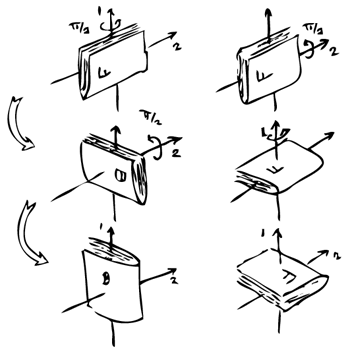

### Symbolic Verifications

In [ ]:
theta_1, theta_2, theta_3=symbols('theta_1 theta_2 theta_3');
R1_theta1=Matrix([[1,0,0],[0,cos(theta_1),-sin(theta_1)],[0,sin(theta_1),cos(theta_1)]])
R2_theta2=Matrix([[cos(theta_2),0,sin(theta_2)],[0,1,0],[-sin(theta_2),0,cos(theta_2)]])
R3_theta3=Matrix([[cos(theta_3),-sin(theta_3),0],[sin(theta_3),cos(theta_3),0],[0,0,1]])

**Composition of Rotations:** Finding the rotation matrix that relates a frame $\mathbf{b}$ to a frame $\mathbf{e}$ that is first a counter clockwise rotation around the first axis by an angle $\theta_1$ and then a counter clockwise rotation around the third axis by an angle $\theta_3$.

The first rotation gives $\mathbf{c}=\mathbf{e}R_1(\theta_1)$ and the second rotation gives $\mathbf{b}=\mathbf{c}\,R_3(\theta_3)$. Then $\mathbf{b}=\mathbf{c}\,R_3(\theta_3)=\mathbf{e}\,\underbrace{R_1(\theta_1)R_3(\theta_3)}_{R_a}$

In [ ]:
Ra=simplify(R1_theta1 @ R3_theta3)
Ra

Lets find the reverse sequence of rotations: That is first rotate about the third axis and then about the first axis.

The first rotation gives $\mathbf{d}=\mathbf{e}R_3(\theta_3)$ and the second rotation gives $\mathbf{b}=\mathbf{d}\,R_1(\theta_1)$. Then $\mathbf{b}=\mathbf{d}\,R_1(\theta_3)=\mathbf{e}\,\underbrace{R_3(\theta_3)R_1(\theta_1)}_{R_b}$



In [ ]:
Rb=simplify(R3_theta3 @ R1_theta1)
Rb

Notice that $\underbrace{R_1(\theta_1) R_3(\theta_3)}_{R_a}\neq \underbrace{R_3(\theta_3)R_1(\theta_1)}_{R_b}$

**Thus in general rotations do not commute**

### Numerical Verification

In [ ]:
theta1=np.pi/3; theta2=np.pi/3; theta3=np.pi/3;
O=[0,0,0]; OP=[1,1,1]; OQ=[1,-1,2];
R1theta1=np.array([[1,0,0],[0,np.cos(theta1),-np.sin(theta1)],[0,np.sin(theta1),np.cos(theta1)]])
R2theta2=np.array([[np.cos(theta2),0,np.sin(theta2)],[0,1,0],[-np.sin(theta2),0,np.cos(theta2)]])
R3theta3=np.array([[np.cos(theta3),-np.sin(theta3),0],[np.sin(theta3),np.cos(theta3),0],[0,0,1]])

In [ ]:
Ra=R1theta1 @ R3theta3; Rb=R3theta3 @ R1theta1;

In [ ]:
#Initiating a figure with a e-frame
fig=go.Figure();
O=[0,0,0];
fig=mr.add_orth_norm_frame(fig,O,np.array([[1,0,0],[0,1,0],[0,0,1]]),[[-1.5,1.5],[-1.5,1.5],[-1.5,1.5]],'blue')
#Adding a frame rotated by Ra
fig=mr.add_orth_norm_frame(fig,O,Ra,[[-1.5,1.5],[-1.5,1.5],[-1.5,1.5]],'red')
#Adding a frame rotated by Rb
fig=mr.add_orth_norm_frame(fig,O,Rb,[[-1.5,1.5],[-1.5,1.5],[-1.5,1.5]],'green')
fig.show()

## Euler's Theorem

Since $det (R)=1$ one can  show that the eignevalues of any $R\in SO(3)$ are of the form $\{1,e^{i\theta},e^{-i\theta}\}$. Thus it follows tht for any $R\in SO(3)$ there exists a $V\in \mathbb{R}^3$ such that $RV=V$. Now since $R$ acts on $\mathbb{R}^3$ by rigid rotations we see that this action leaves all points along  $V$ fixed. Furthermore this also shows that there eixts two frame transformations such that with respect to these transformations $R$ takes the form

\begin{align}
\begin{bmatrix}
1 & 0 & 0\\
0 & \cos{\theta} & -\sin{\theta}\\
0 & \sin{\theta} & \cos{\theta}
\end{bmatrix}.
\end{align}

This shows that every rotation $R$ can be thought of as a rotation about some axis $n$ by some angle $\theta$. This is depicted in the figure below. This result is known as Euler's theorem on rotations.

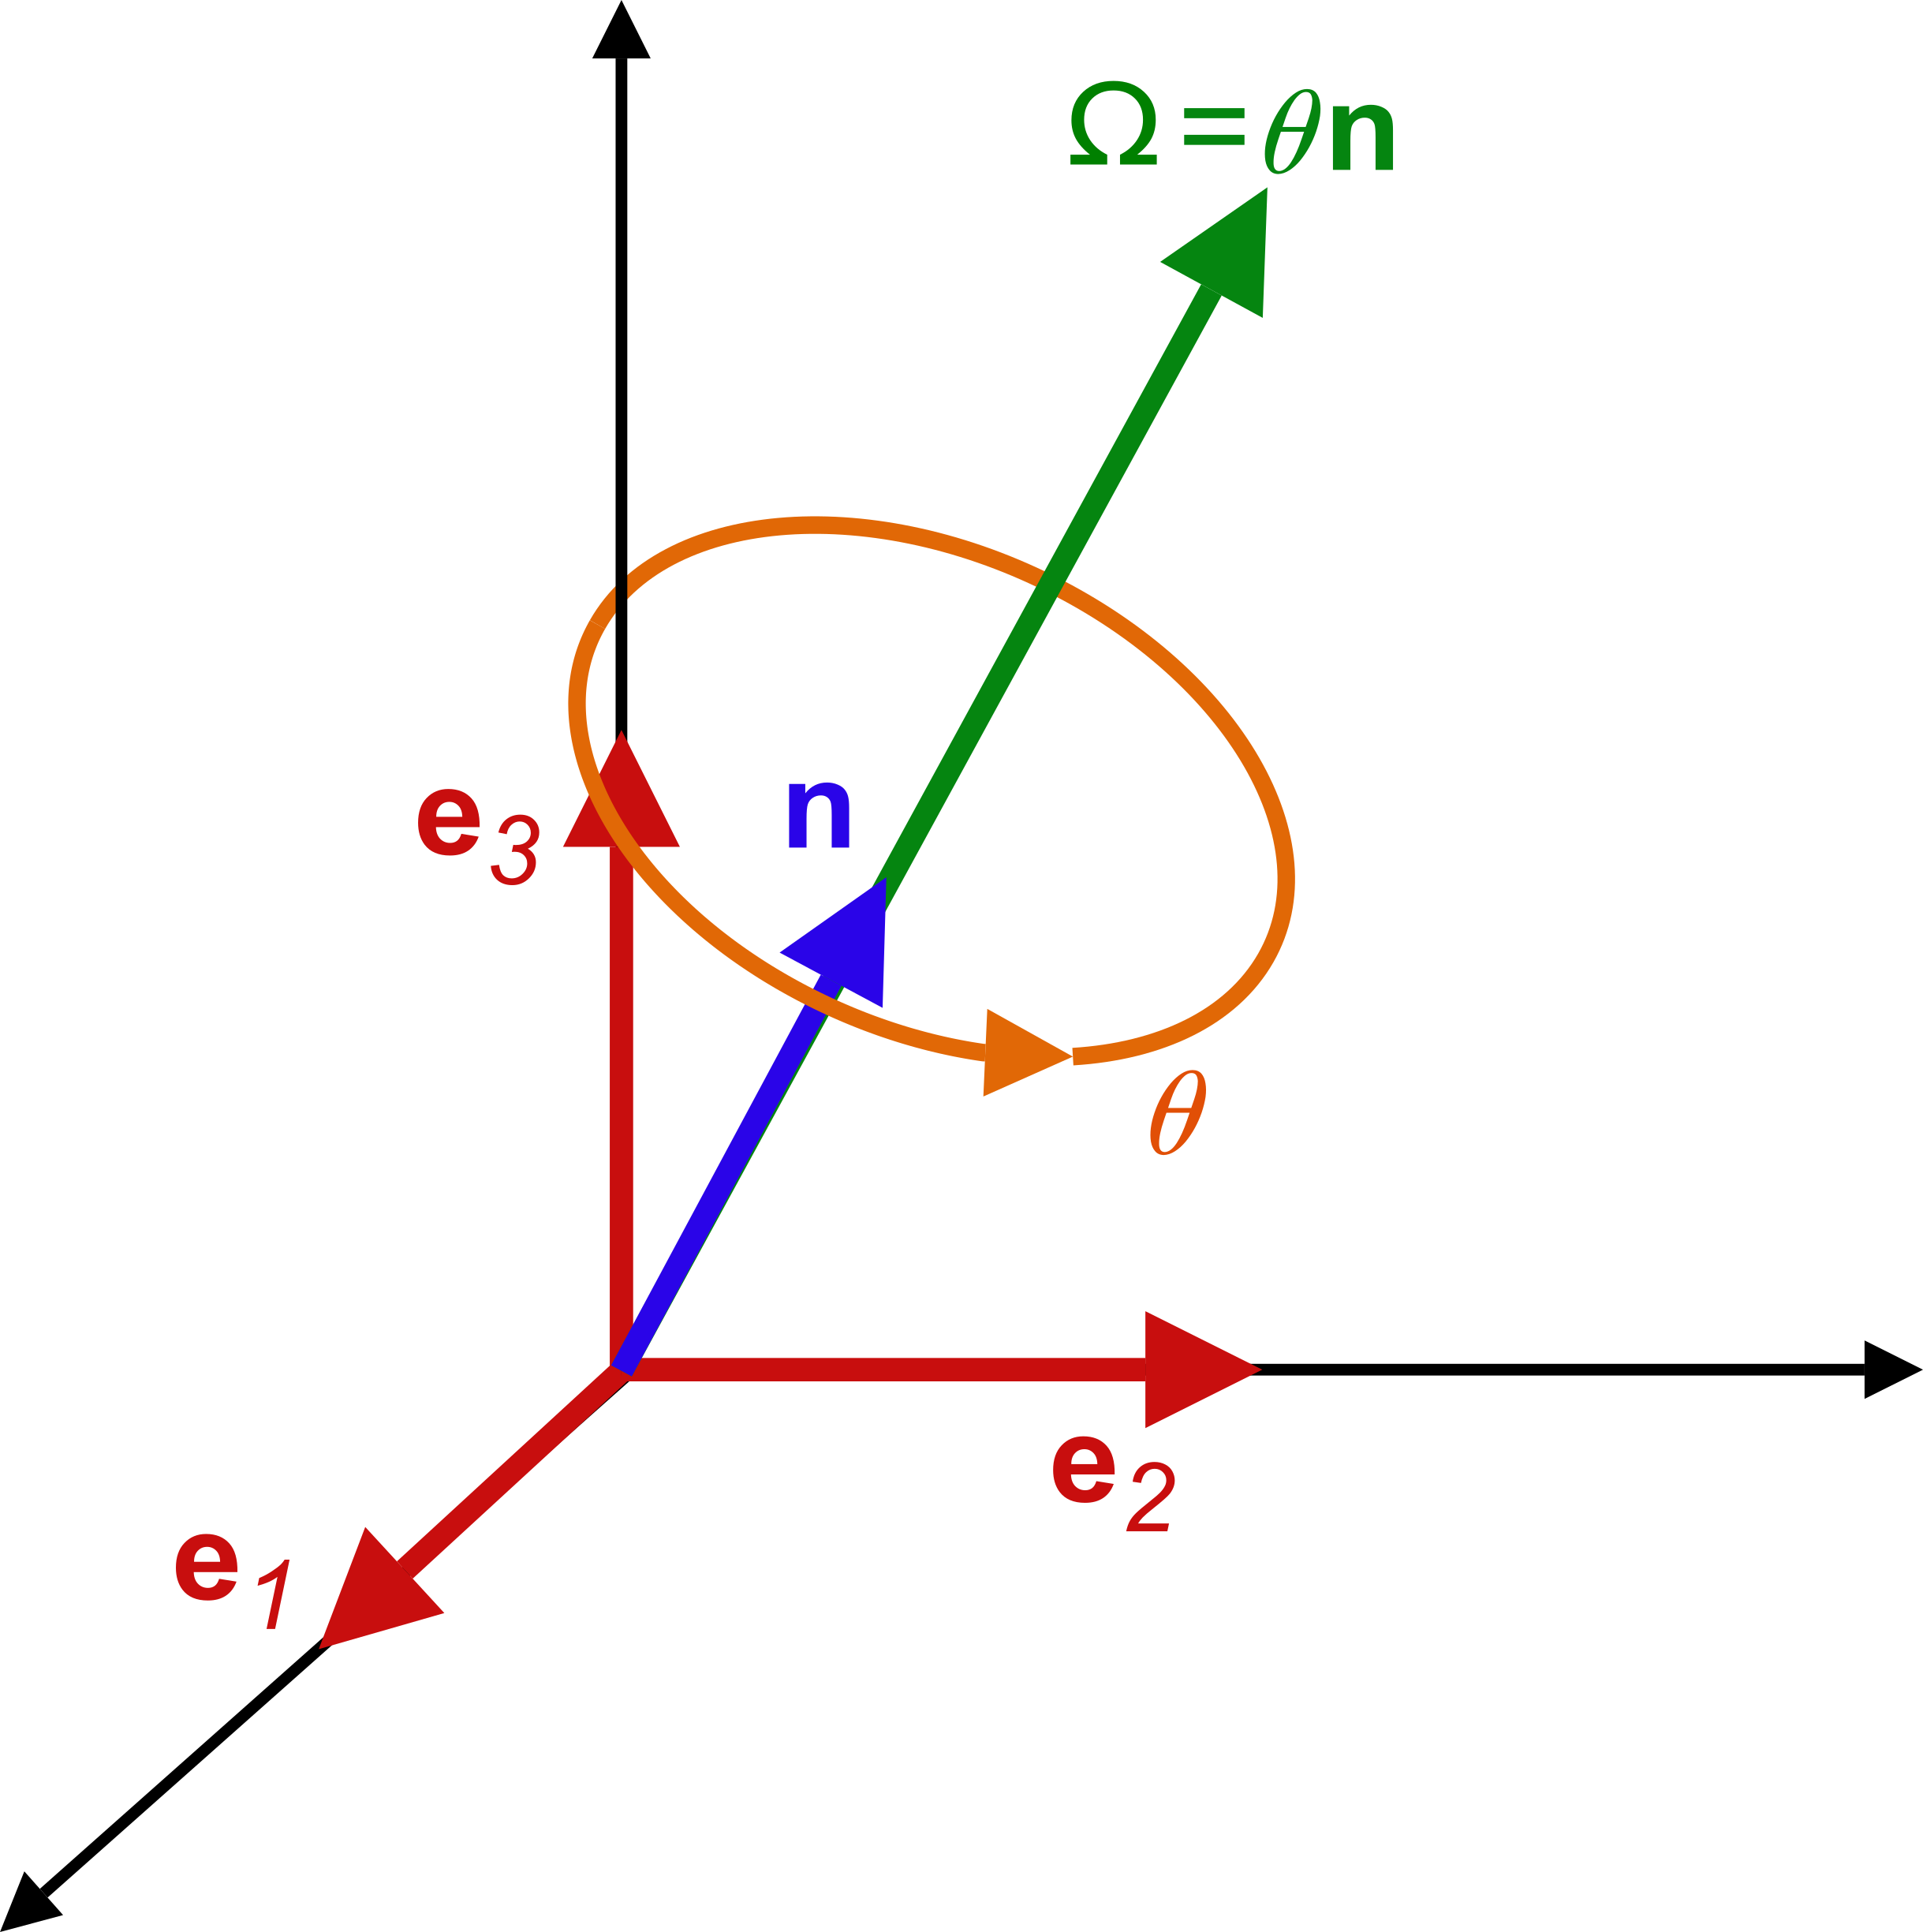

Therefore we see that the space of rotations, $\mathrm{SO}(3)$ can be identified with the solid ball in $\mathbb{R}^3$ with the antipodal points on the boundary identified or by the space of unit tangent vectors on $\mathbb{S}^2$ that is typically denoted by $T_0\mathbb{S}^2$. This confirms our previous conclusion that the dimension of the space $\mathrm{SO}(3)$ is three. On the other hand this also confirms our observation that the space of $SO(3)$ is quite different from $\mathbb{R}^3$. In fact this shows that $SO(3)$ is not isomorphic to $\mathbb{R}^3$. What this implies is that there exists no way of globally parameterizing $SO(3)$ using three parameters.


Since $SO(3)$ is three dimensional any choice of co-ordinates for parameterizing $\mathrm{SO}(3)$ will involve three components. Below we will describe a specific way of assigning coordinates, that are known as Euler angles. But since the preceding discussion shows that $SO(3)$ can not be isomorphic to $\mathbb{R}^3$ there exists no co-ordinate patch that will uniquely specify every point of $\mathrm{SO}(3)$. Thus any choice of Euler angles, or for that matter any three parameter local co-ordinate system on $\mathrm{SO}(3)$ will have points at which they become singular.


### Numerical Verification

In [ ]:
the1=np.pi/3; the2=np.pi/3; the3=np.pi/3;
O=[0,0,0]; OP=[1,1,1]; OQ=[1,-1,2];
R1the1=np.array([[1,0,0],[0,np.cos(the1),-np.sin(the1)],[0,np.sin(the1),np.cos(the1)]])
R2the2=np.array([[np.cos(the2),0,np.sin(the2)],[0,1,0],[-np.sin(the2),0,np.cos(the2)]])
R3the3=np.array([[np.cos(the3),-np.sin(the3),0],[np.sin(the3),np.cos(the3),0],[0,0,1]])
Ra=R1the1 @ R3the3; Rb=R3the3 @ R1the1;

In [ ]:
Ra

In [ ]:
D, V=linalg.eig(Ra)

In [ ]:
T=np.array([V.real.T[2],V.real.T[0],V.imag.T[0]]).T

In [ ]:
T.T @ Ra @ T

## Euler Angle Parameterization of $SO(3)$

We have seen that a seqeucne of rotations correspond to a serier multiplication of rotation matrices.

The $R\in SO(3)$ given by
\begin{align}
R&\triangleq R_{i}(\theta_\alpha)R_{j}(\theta_\beta)R_{k}(\theta_\gamma)
\end{align}
is in $SO(3)$ and corresponds to a rotation first about the $i^{\mathrm{th}}$ axis, then about the $j^{\mathrm{th}}$ axis and then finally about the $k^{\mathrm{th}}$ axis. Thus this process defines a map from $\mathbb{R}^3$ to $SO(3)$ that takes $(\theta_\alpha,\theta_\beta,\theta_\gamma)\in \mathbb{R}^3$ to $R_{ijk}= R_{i}(\theta_\alpha)R_{j}(\theta_\beta)R_{k}(\theta_\gamma)\in SO(3)$

One can show that for any combination of $i,j,k \in \{1,2,3\}$ where not all three $i,j,k$ are the same and no two consequtive indices are the same the resulting map is one-to-one and onto except for a very special set of $(\theta_\alpha,\theta_\beta,\theta_\gamma)$. Thus $(\theta_\alpha,\theta_\beta,\theta_\gamma)$ form a set of local coordinates for $SO(3)$. *Thus we see that $SO(3)$ is a 3-dimensional space. That is one needs three independent quantities to uniquely describe its elements.*

**This is called the $i-j-k$ Euler angle parameterization of $R\in SO(3)$.**


In [ ]:
alpha, beta, gamma=symbols('alpha beta gamma');
R1_alpha=Matrix([[1,0,0],[0,cos(alpha),-sin(alpha)],[0,sin(alpha),cos(alpha)]])
R2_beta=Matrix([[cos(beta),0,sin(beta)],[0,1,0],[-sin(beta),0,cos(beta)]])
R3_gamma=Matrix([[cos(gamma),-sin(gamma),0],[sin(gamma),cos(gamma),0],[0,0,1]])

In [ ]:
#Try out various combinations
simplify(R1_alpha @ R2_beta @ R3_gamma)

##### 3-1-3 Euler Angle Parameterization of $R\in SO(3)$

In [ ]:
theta_1, theta_2, theta_3=symbols('theta_1 theta_2 theta_3');
R1_theta2=Matrix([[1,0,0],[0,cos(theta_2),-sin(theta_2)],[0,sin(theta_2),cos(theta_2)]])
R3_theta1=Matrix([[cos(theta_1),-sin(theta_1),0],[sin(theta_1),cos(theta_1),0],[0,0,1]])
R3_theta3=Matrix([[cos(theta_3),-sin(theta_3),0],[sin(theta_3),cos(theta_3),0],[0,0,1]])

In [ ]:
simplify(R3_theta1 @ R1_theta2 @ R3_theta3)

This parameterization is shown in the figure below.
It is easy to see that  when $\theta_2=0$ or $\theta_2=\pi$ then $R=R_3(\theta_1+\theta_3)$ and hence that there exists no unique $\theta_1,\theta_3$ that describe the orientation of the resulting two frames $\mathbf{e}$ and $\mathbf{b}$. This situation is called \emph{gimbal lock} in the stellite and robotics communities.
This turns out to be a common problem for any type of Euler angles being used. Thus in particular we find that the Euler angles only provide a local isomorphism between $\mathbb{R}^3$ and $SO(3)$.

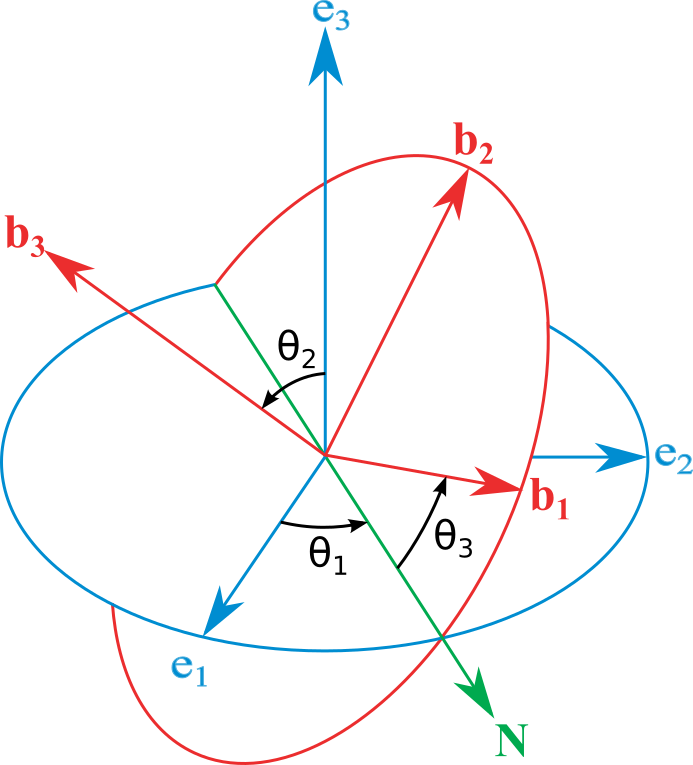

## Unit Quaternion Parameterization of $SO(3)$

Consider the case where an orthonormal frame $\mathbf{b}(t)$ is moving with respect to another orthonormal frame $\mathbf{e}$ such that the origins of the two frames remain coincident. Let $\mathbf{b}(t)=\mathbf{e}\,R(t)$ and $\widehat{\Omega}=R^T\dot{R}$. Consider $\Omega$ and $\omega=R\Omega$ (note that $\widehat{\omega}=\dot{R}R^T$).

In the section titled 'Angular Velocity' we have seen that $\omega$ represents the intantaneous axis of rotation of $\mathbf{b}(t)$ with respect to $\mathbf{e}$ as seen from $\mathbf{e}$. Furthermroe we also saw that the rate of this instantaneous rotation is eaqual to $||\omega||=||\Omega||$. Thus we saw that $\omega$ is the angular velocity of $\mathbf{b}(t)$ with respect to $\mathbf{e}$ as seen from $\mathbf{e}$ and that $\Omega$ is its representation with respect to $\mathbf{b}(t)$.

In this section we will take a closer look at the two equivalent matrix differential equations:
\begin{align}
\dot{R}&=R\widehat{\Omega}\\
\dot{R}&=\widehat{\omega}R
\end{align}
that correspond to $\widehat{\Omega}=R^T\dot{R}$ and $\widehat{\omega}=\dot{R}R^T$ respectively.

Let us concentrate on the solutions of  $\dot{R}=R\widehat{\Omega}$ and everything we will observe for this will have a corresponding simialr interpretation for $\dot{R}=\widehat{\omega}R$.

We note that if one considers element by element then $\dot{R}=R\widehat{\Omega}$ represents nine time varying ODEs. However since $R^TR=I_{3\times 3}$ defines six constraints we see that all the nine differential equations defined by $\dot{R}=R\widehat{\Omega}$ are not independent.


Since $R(t)$ corresponds to an instantaneous rotation about $\Omega$ (as seen in the $\mathbf{b}$ frame) at an instantaneous rate that is equal to $||\Omega||$. Thus if $\Omega$ is a constant then the solution to the following initial value problem
\begin{align}
\dot{R}&=R\widehat{\Omega},\:\:\:\:\:\:\: R(0)=I_{3\times 3},
\end{align}
is a pure rotation about the axis $\Omega$ at a constant angular rate of $\Omega$.
This says that if we define $\theta(t)\triangleq t||\Omega||$ then since $\Omega$ does not depend on $t$ we see that the solution, $R(t)$, to the initial value problem  is a rotation about the axis $\Omega$ by an angle equal to $\theta=t||\Omega||$.
It is easy to verify by direct computation that this solution is explicitly and uniquely given by
\begin{align}
{R}(t)&=\exp{(t\widehat{\Omega})},
\end{align}
where $\exp{(A)}$ denotes the matrix exponential of the matrix $A$.


Setting $t=1$ in ${R}(t)=\exp{(t\widehat{\Omega})}$ we see that $\exp{(\widehat{\Omega})}\in \mathrm{SO}(3)$ for any $\widehat{\Omega}\in \mathrm{so}(3)$ and that it corresponds to a rotation about the axis $\Omega$ by an angle $\theta=||\Omega||$.
This process defines a map $\exp : \mathrm{so}(3) \to \mathrm{SO}(3)$.
By uniqueness of solutions of differential equations we find that the so defined map
$\exp : \mathrm{so}(3) \to \mathrm{SO}(3)$ is locally one-to-one. Showing this is beyond the scope of this lecture notes as it requires advanced mathematical notions involving group theory.

Conversely in the previous section we have seen that teh Euler's theorem says that every $R \in \mathrm{SO}(3)$ can be thought of as a rotation about some axis $\Omega$ and hence that for any given $R$ there exists some $\widehat{\Omega}\in \mathrm{so}(3)$ such that $R=\exp{(\widehat{\Omega})}$. Thus we see that the map $\exp : \mathrm{so}(3) \to \mathrm{SO}(3)$ is onto as well.


**In summary what we have shown is that for every $\Omega$ there is a unique corresponding $R$ given by the matrix exponential $\exp{(\widehat{\Omega})}$ and that for every $R$ there also exists some $\Omega$ such that $R=\exp{(\widehat{\Omega})}$.**



Let us now proceed to find an explicit expression for $\exp{(\widehat{\Omega})}$. Previously we have shown that
\begin{align}
\widehat{\Omega}^2=(\Omega\Omega^T-||\Omega||^2I).
\end{align}
From this it follows that
\begin{align}
\widehat{\Omega}^3=-||\Omega||^2\widehat{\Omega},\:\:\:\:\:\:\:\widehat{\Omega}^4=-||\Omega||^2\widehat{\Omega}^2,\:\:\:\:\:\:\:\widehat{\Omega}^5=||\Omega||^4\widehat{\Omega},\:\:\:\:\:\:\:\cdots
\end{align}
and therefore we can show that
\begin{align}
\exp{\left({\widehat{\Omega}}\right)}&=I+\frac{\sin{||\Omega||}}{||\Omega||}\widehat{\Omega}+\frac{1}{2}\left(\frac{\sin{\frac{||\Omega||}{2}}}{{\frac{||\Omega||}{2}}}\right)^2\widehat{\Omega}^2.
\end{align}
This is famously known as the *Rodrigues formula*.

**We stress again that this corresponds to a rotation about the axis $\Omega$ by an angle $\theta=||\Omega||$**. Thus letting $n=\Omega/||\Omega||$ be the unit length direction along $\Omega$ we can write the above equation also as

\begin{align}
R=\exp{\left(\theta\,{\widehat{n}}\right)}&=I+\sin{\theta}\,\widehat{n}+(1-\cos{\theta})\,\widehat{n}^2.
\end{align}

Since we have seen that every $R \in \mathrm{SO}(3)$ can be written as $R=\exp{(\widehat{\Omega})}$ for some $\widehat{\Omega}\in \mathrm{so}(3)$ we can also conclude that every $R \in \mathrm{SO}(3)$ can be written down using the above expression for some angle $\theta$ and unit direction $n$.
Observe that specifically if $E_1=[1\:\:\:0\:\:\:0]^T,E_2=[0\:\:\:1\:\:\:0]^T,E_3=[0\:\:\:0\:\:\:1]^T$ then the Rodrigues formula gives that
$\exp{(\theta_i\widehat{E}_i)}=R_i(\theta_i)$ corresponds to a rotation about the axis $E_i$ by an angle equal to $\theta_i$.

Let $w=\sin{\left(\frac{\theta}{2}\right)}n$ and
$q_0=\cos{\left(\frac{\theta}{2}\right)}$.  Observe that since $q_0^2+||w||^2=1$ the ordered quadruple of numbers $q=(q_0,w)$ represents a point on the surface of the unit sphere, $\mathbb{S}^3=\{q\in \mathbb{R}^4\:\:\: |\:\:\: ||q||=1\}$, in $\mathbb{R}^4$.  Then re-arranging the above expression we have that every $R\in \mathrm{SO}(3)$ can be written down as

\begin{align*}
R&=I+2q_0\widehat{w}+2\widehat{w}^2.
\end{align*}
for some $(q_0,w)\in\mathbb{S}^3$.

Conversely we also see that for every $q=(q_0,w)\in \mathbb{S}^3$ there is a unique corresponding $R\in \mathrm{SO}(3)$  that is explicitly given by the above formula. Note that, since $-q=(-q_0,-w)\in \mathbb{S}^3$ also gives the same $R$ that is given by $q=(q_0,w)\in \mathbb{S}^3$, this correspondence is two-to-one. In summary, we have the following:

The group of rotations $\mathrm{SO}(3)$ is isomorphic to $\mathbb{S}^3/\{1,-1\}$ where the isomorphism is explicitly given by the above expression
$R=I+2q_0\widehat{w}+2\widehat{w}^2$.
Here $R$ corresponds to a rotation about $w$ by an angle equal to $\theta =2\cos^{-1}({q_0})$.
Using algebraic manipulations it can also be shown that, in terms of $(q_0,w)\in \mathbb{S}^3$, the differential equation $\dot{R}=R\widehat{\Omega}$ becomes

\begin{align}
\left[\begin{array}{c}\dot{q}_0 \\ \dot{w}
\end{array}\right] &=
\frac{1}{2}\left[\begin{array}{c}-\Omega \cdot w \\ q_0\Omega-\Omega\times {w}
\end{array}\right].
\end{align}


The unit sphere in $\mathbb{R}^4$, denoted by $\mathbb{S}^3=\{q\in \mathbb{R}^4 \:\:\:|
\:\:\: ||q||=1\}$ is also known as the space of *unit quaternions*. We conclude this section by noting that the unit quaternion $q=(q_0,w)$ that correspond to a given rotation matrix $R$ can be found using the following two expressions:
\begin{align}
\mathrm{trace}(R)&=-1+4q_0^2=2\cos \theta +1,\\
R-R^T&=4q_0 \widehat{w}=4\cos{\left(\frac{\theta}{2}\right)} \widehat{w}.
\end{align}
The first expression determines $q_0=\cos{\frac{\theta}{2}}$ and the second expression determines $w$.

### Numerical Verifications

In [ ]:
mr.r_from_quaternions

In [ ]:
q=mr.q_from_axis_angles(np.pi/2,[1,1,0]/np.sqrt(2))
print(q)

In [ ]:
R=mr.r_from_quaternions(q);

In [ ]:
mr.r_from_quaternions

In [ ]:
fig=go.Figure()
fig=mr.add_orth_norm_frame(fig,[0,0,0],np.eye(3),[[-1.5,1.5],[-1.5,1.5],[-1.5,1.5]],'blue')
fig=mr.add_orth_norm_frame(fig,[0,0,0],R,[[-1.5,1.5],[-1.5,1.5],[-1.5,1.5]],'red')
fig.show()

## Integration of Rotational Kinematics

We have seen that the solution to the initial value problem $\dot{R}=R\widehat{\Omega}$, $R(0)=R_0$ is explicitly given by $R(t)=R_0\exp{(t\widehat{\Omega})}$ if ${\Omega}$ is a constant.

If $\Omega (t)$ is time varying then, in general, there exists no such explicit solution and one needs to resort to numerical methods of finding an approximate solution.

The above explict solution gives us one suach natural scheme that is based on the Euler's method of approximation.

Consider a discrete sequence of time points $\{t_0,t_1,\cdots, t_k,t_{k+1},\cdots,t_N\}$ at which we need to aproximate the solution of our initial value problem. Let $R_k\triangleq R(t_k)$ and $\Omega_k\triangleq \Omega(t_k)$ and $\Delta t_k\triangleq (t_{k+1}-t_k)$. The assuming that $\Omega(t)\approx \Omega(t_k)$  during the time interval $[t_k,t_{k+1}]$ we see that

\begin{align}
R_{k+1}&\approx R_k\exp{(\Delta t_k\Omega_k)}
\end{align}
with $R_0=R(0)$. The accuracy of this approximation increases as $\Delta t_k$ beocmes small.

Note that we can explicitly compute $\exp{(\Delta t_k\Omega_k)}$ using the Euler-Rodrigues formula
\begin{align}
\exp{(\Delta t_k\Omega_k)}=I+2{q_0}_k\widehat{w}_k+2\widehat{w}^2_k
\end{align}
where
\begin{align}
\theta_k&=\Delta t_k||\Omega_k||,\\
{q_0}_k&=\cos{\left(\frac{\theta_k}{2}\right)},\\
w_k &= \sin{\left(\frac{\theta_k}{2}\right)}\frac{\Omega_k}{||\Omega_k||}.
\end{align}

#### Numerical Example

Consider $\dot{R}=R\widehat{\Omega}$ where $\Omega(t)=[\sin{t},\cos{t},0]$. We are intersted in finding the rotation matrix $R$ when $t=2\pi$ with $R(0)=I_{3\times 3}$.

Consder the equally spaced sequence of time points $[0,t_1,t_2,\cdots,2\pi]$ where $\Delta t_k=2\pi/10$.

In [ ]:
R0=np.eye(3);
listR=[R0];
t=np.linspace(0,2*np.pi,11);
for k in t:
  Omega_k=[np.sin(k),np.cos(k),0];
  theta_k=(2*np.pi/11)*linalg.norm(Omega_k);
  n_k=Omega_k/linalg.norm(Omega_k);
  q_k=mr.q_from_axis_angles(theta_k,n_k)
  R0=R0 @ mr.r_from_quaternions(q_k);
  listR+=[R0]

In [ ]:
n=11
fig=go.Figure()
fig=mr.add_orth_norm_frame(fig,[0,0,0],np.eye(3),[[-1.5,1.5],[-1.5,1.5],[-1.5,1.5]],'blue')
fig=mr.add_orth_norm_frame(fig,[0,0,0],listR[n],[[-1.5,1.5],[-1.5,1.5],[-1.5,1.5]],'red')
fig.show()

In [ ]:
cube_dimensions={'l':4, 'w':2,'h':1, 'xp':2, 'yp':1, 'zp':0.5}
XX0=mr.cube_{v_i}ertices(cube_dimensions)
XX=[];
for R in listR:
  XX+=[[R @ XX0]]
fig=mr.animated_cube_flat_shading(XX,'Cube')

## Importing Python Packages

### Tracking helper methods

In [ ]:
def referenceConfig(qq,refParameters,t):
  II=refParameters;
  dotOmegart=np.array([0,.01,0]);
  dotPir=II@dotOmegart;
  Omegart=np.array([0,0,0])+dotOmegart*t;
  Pir=II@Omegart;
  thetaOmegart=linalg.norm(Omegart)*t+0*np.pi;
  nOmegart=Omegart/(0.000001+linalg.norm(Omegart));
  qOmegart=np.concatenate(([np.cos(thetaOmegart/2)],np.sin(thetaOmegart/2)*nOmegart));
  Rr=qq.RfromQuaternions(qOmegart);
  return [Rr,Pir,dotPir]

def controller(qq,parameters,t,X,taue,fe):
  #Fully Actuated PD Controller
  II=parameters['II'];
  R=X[0][0]; omega=X[1]; piI=X[3];
  [Rr,Pir,dotPir]=referenceConfig(qq,II,t);
  pir=Rr@Pir;
  omegar=Rr@linalg.inv(II)@Pir;
  Re=Rr@R.T;
  pie=R @ II @ Rr.T @ (omegar-Re@omega);
  K=np.array([[1,0,0],[0,2,0],[0,0,3]]);
  eRhat=0.5*(Re@K-K@Re.T);
  eR=np.array([-eRhat[1,2],eRhat[0,2],-eRhat[0,1]]);
  tauu=(R@dotPir+qq.hatMatrix(omega)@pir)-0.*taue+(4*eR+10*pie+2.*piI)
  fu=-fe+np.array([0,0,0]);
  return [tauu,fu,eR,pie]

def controller_dynamics(qq, t,X,taue,fe,parameters):
  Xc=X[3];
  Uc=controller(qq,parameters,t,X,taue,fe);
  eR=Uc[2];
  dXc=eR;
  #print(eR)
  return dXc

In [ ]:
#!pip install plotly Uncomment if you have not installed already

In [ ]:
import numpy as np
import scipy as sp
from scipy.integrate import odeint
import math
from numpy import linalg
import sympy

from sympy import symbols
from sympy import *

import plotly.graph_objects as go
import plotly.express as px

In [ ]:
# Install the simulation helpers
!pip install --quiet "git+https://github.com/mugalan/classical-mechanics-from-a-geometric-point-of-view.git#egg=rigid-body-sim"
import sims
mr = sims.RigidBodySim()

# Group Actions